# Probability of Fire (PoF) — Training

**Master:** Physics of Data \
**Course:** Laboratory of Computational Physics (LCP), Module B \
**Authors:** Gabriela Landinez Rangel, Andres Rojas Lozano, Fatemeh Dashti, Arash Taraz Jamshidi

This notebook was created by us to present the final project for LCP MOD B, However it is based on public available code from the Probability of Fire project by ECMWF: https://ecmwf.github.io/AI-Probability-of-Fire/pof-data-generator/. With this work, we aim to provide a clear, but friendly, guide with straightforward instructions and detailed explanations for students who, like us, want to reproduce this framework.

### Python libraries

Again, let's first import all the necessary Python libraries.

In [1]:
import pandas as pd
import os
import time
import seaborn as sns
import joblib
import matplotlib.pyplot as plt
import xgboost as xgb
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split , GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, recall_score, precision_score, f1_score, average_precision_score

In [29]:
from matplotlib.colors import LinearSegmentedColormap

cmap_fire = LinearSegmentedColormap.from_list(
    'fire_moccasin_pink', ['#FFE4B5', '#FF1493']
)

### Load Training Data 

You need to load the `training_data.parquet` file generated in the previous notebook (the data generator). Remember this file contains all grid coordinates where total fuel was greater than 0, along with the corresponding weather, fuel, and ignition source variables, plus the active fire label.

In [2]:
df = pd.read_parquet("./data/training_data.parquet") 
print("Columns:", list(df.columns))

Columns: ['AF', 'PR', 'T2', 'RH', 'WS', 'FU_LL', 'FU_LW', 'FU_DF', 'FU_DW', 'DF', 'DW', 'LF', 'PO', 'RD']


### Define Features and labels

For training a model we need to separate the dataset into features (X) and a target (y). The target also called label is simply the one we want to predict. In our case it is the AF column, which indicates if there is an active fire or not. All remaining columns are used as features.

In [3]:
target_col = "AF" 
feature_cols = [c for c in df.columns if c not in ["AF"]]

X = df[feature_cols]
y = df[target_col]

### Train and test split

Now, we split the data into training and test sets, using 80% for training and 20% for testing. `train_test_split` splits arrays or matrices into random train and test subsets.

**Important:** Since fire events are rare compared to non-fire events (we had more NaNs than 1s in the AF file), we need to preserve the class balance between AF (1) and non-AF (0) cases in both sets (train and test). Otherwise, the split could generate train or test sets without any occurrence of a particular class. `stratify=y` tells `train_test_split` to preserve the same proportion of each class in both the train and test sets as in the original dataset.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

We can easily check the proportion of each class is indeed preserved as follows.

In [5]:
counts = y_train.value_counts()
proportion = y_train.value_counts(normalize=True)
print(counts)
print(proportion)

AF
0.0    171731
1.0      1255
Name: count, dtype: int64
AF
0.0    0.992745
1.0    0.007255
Name: proportion, dtype: float64


In [6]:
counts = y_test.value_counts()
proportion = y_test.value_counts(normalize=True)
print(counts)
print(proportion)

AF
0.0    42933
1.0      314
Name: count, dtype: int64
AF
0.0    0.992739
1.0    0.007261
Name: proportion, dtype: float64


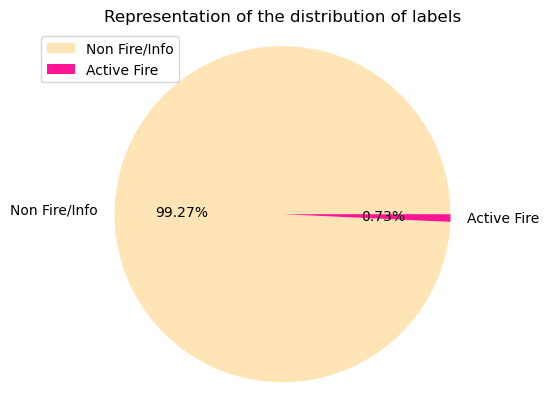

In [17]:
plt.pie(counts, labels=["Non Fire/Info", "Active Fire"], autopct='%1.2f%%', startangle=0, colors=["moccasin",'deeppink'])
plt.legend(loc="best", fontsize=10)
plt.axis('equal')
plt.title('Representation of the distribution of labels')
plt.show()

The cells above confirm that proportion is preserved for both train and test.

### Set up and train the model

You will train an XGBoost binary classifier using the training set. XGBoost (eXtreme gradient boosting) is a learning method based on the implementation of gradient-boosted decision trees, typically used for supervised learning tasks, particularly regression and classification problems such as ours. 

The XGBoost hyperparameters are (https://ecmwf.github.io/AI-Probability-of-Fire/pof-trainer/):

| Parameter | Description |
|---|---|
| `objective="binary:logistic"` | Specifies that this is a binary classification problem. The model outputs probabilities between 0 and 1 using a logistic function. |
| `tree_method="hist"` | Uses the histogram-based algorithm to speed up training, especially for large datasets. It groups feature values into discrete bins instead of processing each unique value. |
| `n_estimators=300` | The number of boosting rounds (trees) to build. Higher values can improve accuracy but may increase training time or risk overfitting. |
| `max_depth=8` | Maximum depth of each decision tree. Deeper trees can model more complex patterns but may overfit the data. |
| `learning_rate=0.1` | Shrinks the contribution of each tree. Lower values make learning slower but more robust; typically balanced with `n_estimators`. |
| `subsample=0.8` (optional) | Fraction of the training data used for each tree. Prevents overfitting and increases generalization. Default is 1.0 (use all data). |
| `colsample_bytree=0.8` (optional) | Fraction of features (columns) randomly sampled for each tree, adding diversity and reducing overfitting. |
| `eval_metric="logloss"` | Evaluation metric for binary classification. Measures the model's prediction accuracy in terms of probability calibration (lower is better). |
| `random_state=42` (optional) | Sets the random seed for reproducibility. Ensures consistent results when running the code multiple times. |
| `n_jobs=-1` | Uses all available CPU cores for parallel computation, speeding up training. |

In [8]:
# -----------------------------
# TRAIN CLASSIFIER
# -----------------------------

print("Training XGBoost Binary Classifier...")
start_time = time.time()

model = XGBClassifier(
    objective="binary:logistic",
    tree_method="hist",
    n_estimators=300,
    max_depth=8, 
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

end_time = time.time()
print(f"✅ Training completed in {end_time - start_time:.2f} seconds")

Training XGBoost Binary Classifier...
✅ Training completed in 1.25 seconds


### Evaluate the model

Then is necesary to do an implementation of the model over the test data, allowing us to interpretate how well is performing the classification. This is done by the computation of the "Confusion Matrix" that has 4 different categories related to the predicted label and the true or false value.

In [9]:
# ORIGINAL VERSION

# -----------------------------
# EVALUATE MODEL
# -----------------------------

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

print("\nConfusion Matrix:")
cm_1 = confusion_matrix(y_test, y_pred)
print(cm_1)


Classification report:
              precision    recall  f1-score   support

         0.0      0.993     1.000     0.996     42933
         1.0      0.429     0.048     0.086       314

    accuracy                          0.993     43247
   macro avg      0.711     0.524     0.541     43247
weighted avg      0.989     0.993     0.990     43247

ROC-AUC: 0.971

Confusion Matrix:
[[42913    20]
 [  299    15]]


**Of actual fires, how many were caught?** 15/314 = 4.8% \
**Of predicted fires, how many were real?** 15/35 = 42.9%

### Evaluate a slightly different model

Since the dataset is highly imbalanced (fire events are rare), we tried to generate predictions using a custom threshold of 0.3 instead of the default 0.5.

In [10]:
# VERSION WITH THRESHOLD

threshold=0.3

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1] # probability

print("\nClassification report:")
print(classification_report(y_test,(y_proba>=threshold).astype(int)))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.3f}")

# Confusion matrix
print("\nConfusion Matrix:")
cm_2=confusion_matrix(y_test,(y_proba>=threshold).astype(int))
print(cm_2)


Classification report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00     42933
         1.0       0.32      0.14      0.19       314

    accuracy                           0.99     43247
   macro avg       0.66      0.57      0.59     43247
weighted avg       0.99      0.99      0.99     43247

ROC-AUC: 0.971

Confusion Matrix:
[[42841    92]
 [  271    43]]


**Of actual fires, how many were caught?** 43/314 = 13.7% \
**Of predicted fires, how many were real?** 43/135 = 31.9%

### Hyperparameter tuning

Due to the low values of the F1-score and the high number of false negative labels in the test implementation, we propose the search of best hyperparameters by the GridSearch method, which allows us to try multiple combinations of values in the search to optimize the model predictions, oriented to maximize the number of true positive values (1 : Active Fire)

In [37]:
%%time

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

pipeline_xgb = Pipeline([
    ("model", XGBClassifier(
        #n_estimators=2000,
        objective="binary:logistic",
        eval_metric= "aucpr",
        #scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
        tree_method="hist",
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    ))
])

# The hyperparameters to be tuned and the values that are going to be tested
param_grid_xgb = {
    "model__learning_rate": [0.03, 0.1, 0.15],
    "model__max_depth": [6, 8, 10],
    "model__min_child_weight": [5, 10],
    "model__n_estimators": [500, 800, 1000],
    "model__subsample": [0.8, 1.0],
    "model__scale_pos_weight": [68, 45],
    
    

}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# Grid search oriented to ROC-AUC
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Fit on training split; use validation split for early stopping inside XGBoost
grid_search_xgb.fit(
    X_tr,
    y_tr,
    model__eval_set=[(X_val, y_val)],
    model__verbose=False
)

print("Best XGBoost parameters:")
print(grid_search_xgb.best_params_)
best_xgb = grid_search_xgb.best_estimator_
print(f"Best XGBoost ROC-AUC CV: {grid_search_xgb.best_score_:.4f}")

Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best XGBoost parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 10, 'model__min_child_weight': 5, 'model__n_estimators': 500, 'model__scale_pos_weight': 68, 'model__subsample': 0.8}
Best XGBoost ROC-AUC CV: 0.2358
CPU times: user 29.1 s, sys: 1.04 s, total: 30.1 s
Wall time: 1min 47s


In [38]:
y_pred = best_xgb.predict(X_test)
y_proba = best_xgb.predict_proba(X_test)[:, 1]
cm_3=confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       1.00      0.96      0.98     42933
         1.0       0.12      0.82      0.21       314

    accuracy                           0.95     43247
   macro avg       0.56      0.89      0.59     43247
weighted avg       0.99      0.95      0.97     43247



Text(0.5, 1.0, 'Confusion Matrix with best hyperparameters')

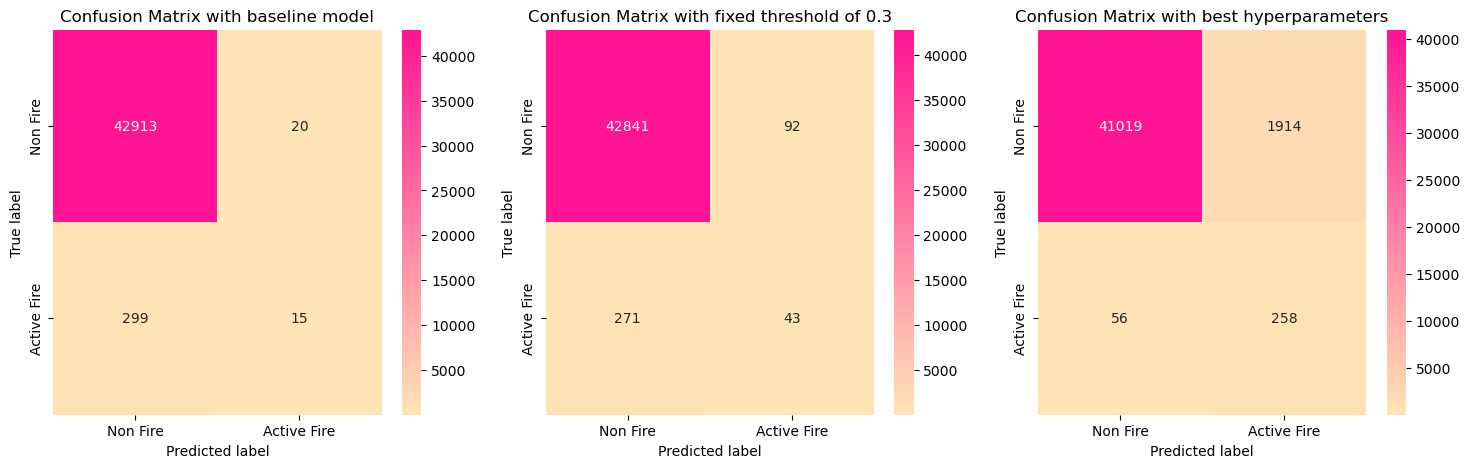

In [39]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Non Fire", "Active Fire"]
sns.heatmap(cm_1, annot=True, fmt="d", cmap=cmap_fire, xticklabels=labels, yticklabels=labels, ax=ax1)
ax1.set_xlabel("Predicted label")
ax1.set_ylabel("True label")
ax1.set_title("Confusion Matrix with baseline model")
sns.heatmap(cm_2, annot=True, fmt="d", cmap=cmap_fire, xticklabels=labels, yticklabels=labels, ax=ax2)
ax2.set_xlabel("Predicted label")
ax2.set_ylabel("True label")
ax2.set_title("Confusion Matrix with fixed threshold of 0.3")
sns.heatmap(cm_3, annot=True, fmt="d", cmap=cmap_fire, xticklabels=labels, yticklabels=labels, ax=ax3)
ax3.set_xlabel("Predicted label")
ax3.set_ylabel("True label")
ax3.set_title("Confusion Matrix with best hyperparameters")

### Analysis

/home/gaby/anaconda3/envs/pof/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/home/gaby/anaconda3/envs/pof/lib/python3.12/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


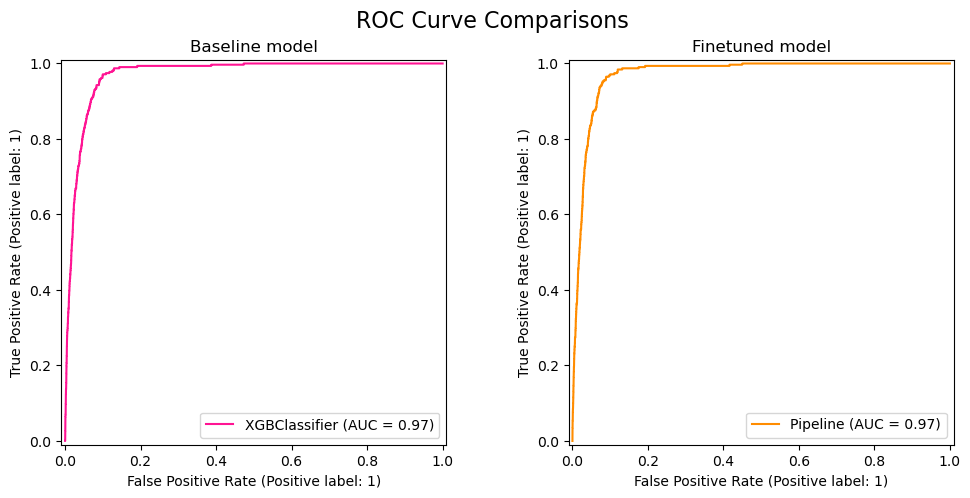

In [40]:
# -----------------------------
# PLOT ROC CURVE 
# -----------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1,color='deeppink')
ax1.set_title("Baseline model") 
RocCurveDisplay.from_estimator(best_xgb, X_test, y_test, ax=ax2,color='darkorange')
ax2.set_title("Finetuned model") 


fig.suptitle("ROC Curve Comparisons", fontsize=16)
#plt.tight_layout()

os.makedirs("./outputs", exist_ok=True)
plt.savefig("./outputs/POF_ROC.png", dpi=300) 
plt.show()
plt.close()

XGBoost allow us to calculate feature scores that rank the importance of various features for classification

<Figure size 1000x600 with 0 Axes>

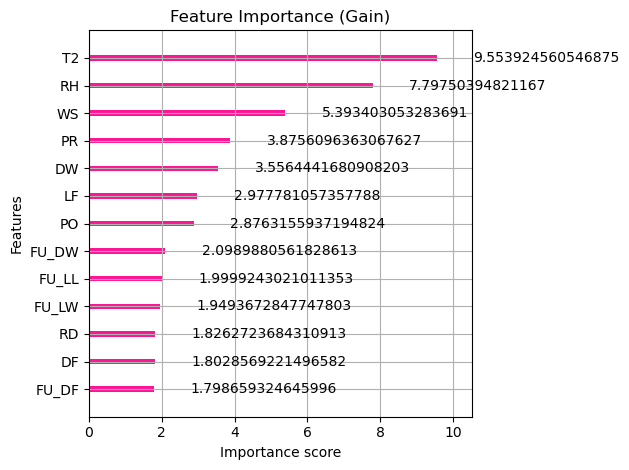

In [41]:
# -----------------------------
# PLOT FEATURE IMPORTANCE
# -----------------------------

plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=20, importance_type="gain",color='deeppink')
plt.title("Feature Importance (Gain)")
plt.tight_layout()
plt.savefig("./outputs/POF_importance.png", dpi=300)
plt.show()
plt.close()

### Saving the model

In [42]:
# -----------------------------
# SAVE MODEL
# -----------------------------
out_model = "./data/POF_model.joblib"
joblib.dump(model, out_model, compress=3)
print(f"Model saved → {out_model}")

Model saved → ./data/POF_model.joblib
